## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





Text(0, 0.5, 'Frequenza percentuale di teste')

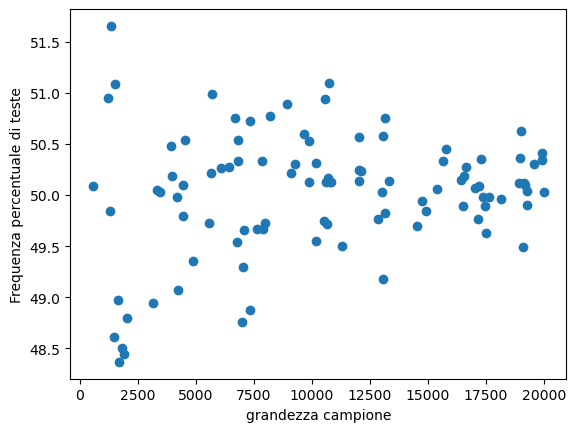

In [43]:
import numpy as np
import random
import matplotlib.pyplot as plt
def lancioMoneta(n):
    # t = testa
    # c = croce
    lanci = np.random.choice(["t","c"],n,True,p=[0.5,0.5])
    return (len(lanci[lanci == "t"])/n)*100

test = []
campione = []
for i in range(100):
    a = random.randint(10,20000)
    campione.append(a)
    test.append(lancioMoneta(a))

plt.scatter(campione,test)
plt.xlabel("grandezza campione")
plt.ylabel("Frequenza percentuale di teste")

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Rimuovi le righe dove il valore di 'Age' è mancante
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mmostrando insieme i dati di uomini e donne

In [49]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


(714, 12)
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          529
Embarked         2
dtype: int64


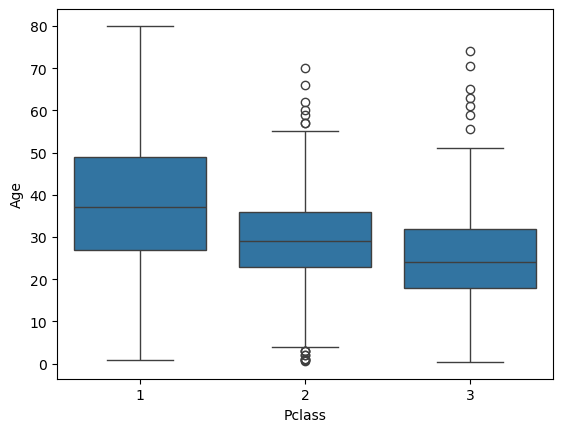

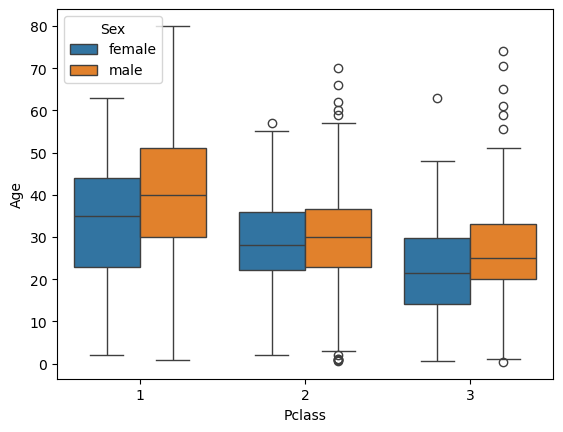

In [90]:
# 1
print(df.shape)
# 2
print(abs(df.notna() - 1).sum())
#3 
# df['Embarked'].fillna(df['Embarked'].mode(), inplace= True) 
# ^ disattivo questa riga solo perché mi da un avviso di pandas, ma funziona
#4
df.dropna(subset='Age', inplace=True)
#5
df.duplicated().sum() # non sembrano esserci
#6
df.groupby('Pclass')['Age'].mean()
#7
sns.boxplot(df, x = 'Pclass', y = 'Age')
plt.show()
#8 
sns.boxplot(df, x = 'Pclass', y = 'Age', hue= 'Sex')
plt.show()

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


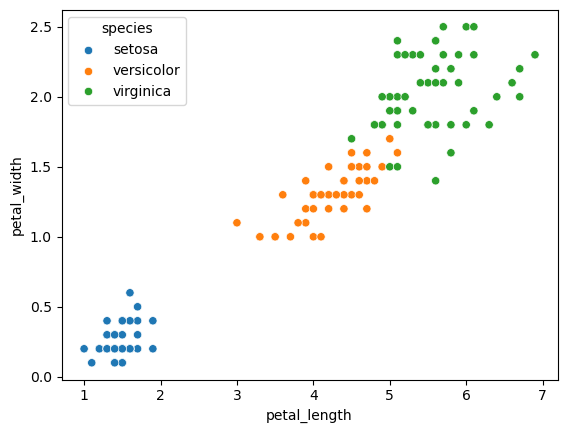

               mean   min    max
species                         
setosa       0.3656  0.11   0.96
versicolor   5.7204  3.30   8.64
virginica   11.2962  7.50  15.87


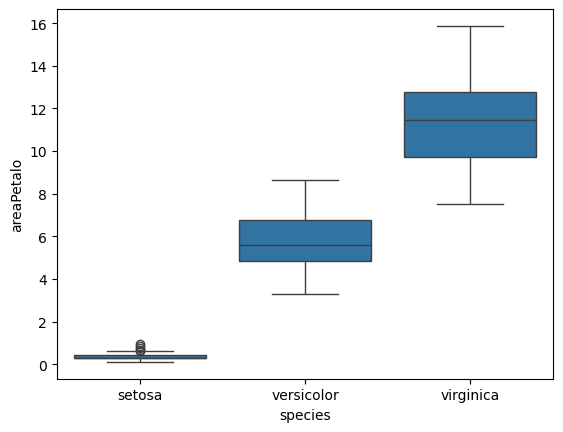

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
print(df.head())

# 1 
print(df['species'].value_counts())

# 2
df.groupby('species')[['petal_width','petal_length']].mean()
# 3
sns.scatterplot(data = df, x = 'petal_length',y = 'petal_width', hue = 'species') # è giusto?
plt.show()
# 4
df['areaPetalo'] = df['petal_length'] * df['petal_width']
print(df.groupby('species')['areaPetalo'].agg(['mean','min','max']))

#5 
sns.boxplot(data = df, x = 'species', y = 'areaPetalo')
plt.show()